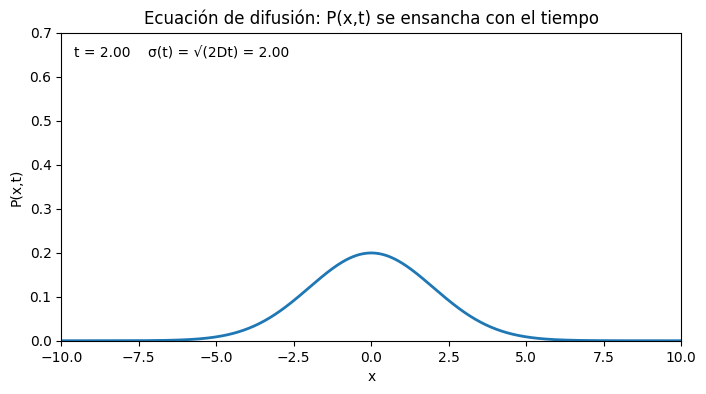

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ---------- Parámetros ----------
D = 1.0
y0 = 0.0
t_max = 2.0
n_frames = 200

# malla espacial
x = np.linspace(-10, 10, 1200)

def P_diffusion(x, t, D=1.0, y0=0.0):
    """Solución fundamental de la ecuación de difusión con delta inicial."""
    if t <= 0:
        # aproximación muy angosta para t=0
        eps = 1e-3
        return (1/np.sqrt(4*np.pi*D*eps))*np.exp(-(x-y0)**2/(4*D*eps))
    return (1/np.sqrt(4*np.pi*D*t))*np.exp(-(x-y0)**2/(4*D*t))

# ---------- Figura ----------
fig, ax = plt.subplots(figsize=(8, 4))
line, = ax.plot([], [], lw=2)
ax.set_xlim(x.min(), x.max())
ax.set_ylim(0, 0.7)
ax.set_xlabel("x")
ax.set_ylabel("P(x,t)")
title = ax.set_title("Ecuación de difusión: P(x,t) se ensancha con el tiempo")

# Texto con sigma(t)
text = ax.text(0.02, 0.92, "", transform=ax.transAxes)

def init():
    line.set_data([], [])
    text.set_text("")
    return line, text

def update(frame):
    t = (frame / (n_frames - 1)) * t_max
    P = P_diffusion(x, t, D=D, y0=y0)
    line.set_data(x, P)
    sigma = np.sqrt(2*D*t)
    text.set_text(f"t = {t:.2f}    σ(t) = √(2Dt) = {sigma:.2f}")
    return line, text

anim = FuncAnimation(fig, update, frames=n_frames, init_func=init, blit=True)

# ---------- Guardar ----------
# Opción 1: MP4 (recomendado si tienes ffmpeg instalado)
anim.save("difusion.mp4", fps=30, dpi=160)

# Opción 2: GIF (si tienes pillow)
# anim.save("difusion.gif", fps=30, dpi=120)

plt.show()

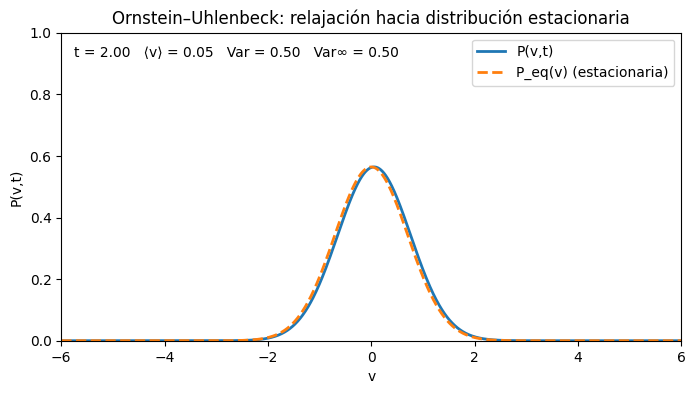

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ---------- Parámetros OU ----------
gamma = 2.0
Dv = 1.0
t_max = 2.0
n_frames = 200

# malla en velocidad
v = np.linspace(-6, 6, 1200)

# Condición inicial: delta en v0 (la aproximamos con gaussiana angosta)
v0 = 3.0
eps0 = 0.03  # ancho inicial pequeño
P0 = (1/np.sqrt(2*np.pi*eps0**2))*np.exp(-(v - v0)**2/(2*eps0**2))

def ou_mean_var(t, v0, gamma, Dv):
    """Media y varianza exactas del proceso OU con V(0)=v0."""
    m = v0*np.exp(-gamma*t)
    var = (Dv/gamma)*(1 - np.exp(-2*gamma*t))
    return m, var

def P_ou(v, t, v0, gamma, Dv):
    """Solución exacta para OU con condición inicial delta en v0."""
    m, var = ou_mean_var(t, v0, gamma, Dv)
    # para t~0, var -> 0, evitamos división por cero:
    var = max(var, 1e-6)
    return (1/np.sqrt(2*np.pi*var))*np.exp(-(v - m)**2/(2*var))

# Distribución estacionaria (equilibrio): gaussiana con var = Dv/gamma
var_inf = Dv/gamma
P_eq = (1/np.sqrt(2*np.pi*var_inf))*np.exp(-(v**2)/(2*var_inf))

# ---------- Figura ----------
fig, ax = plt.subplots(figsize=(8, 4))
line, = ax.plot([], [], lw=2, label="P(v,t)")
eq_line, = ax.plot(v, P_eq, lw=2, linestyle="--", label="P_eq(v) (estacionaria)")
ax.set_xlim(v.min(), v.max())
ax.set_ylim(0, 1.0)
ax.set_xlabel("v")
ax.set_ylabel("P(v,t)")
ax.legend()
title = ax.set_title("Ornstein–Uhlenbeck: relajación hacia distribución estacionaria")

text = ax.text(0.02, 0.92, "", transform=ax.transAxes)

def init():
    line.set_data([], [])
    text.set_text("")
    return line, text, eq_line

def update(frame):
    t = (frame / (n_frames - 1)) * t_max
    P = P_ou(v, t, v0=v0, gamma=gamma, Dv=Dv)
    line.set_data(v, P)
    m, var = ou_mean_var(t, v0, gamma, Dv)
    text.set_text(f"t = {t:.2f}   ⟨v⟩ = {m:.2f}   Var = {var:.2f}   Var∞ = {var_inf:.2f}")
    return line, text, eq_line

anim = FuncAnimation(fig, update, frames=n_frames, init_func=init, blit=True)

# ---------- Guardar ----------
anim.save("ornstein_uhlenbeck.mp4", fps=30, dpi=160)
# anim.save("ornstein_uhlenbeck.gif", fps=30, dpi=120)

plt.show()